# Executed results and a terse exact peer

This notebook is offline. The saved results are historical, not freshly executed API calls. The broad pilot used 14,568 judgments; a separately recorded 36-judgment source-label correction brought the execution total to 14,604. There were 800 operator prompts and 750 candidate strategy–target pairs, not 800 implemented reasoning algorithms or 750 scientifically validated debiasing methods.

**Saved outputs are included below.** Gated API examples replay explicitly labeled historical results in offline mode; they do not make fresh API calls. Set `JEV_LAB_LIVE=1` with your own key only to run new inference. The smaller frontier demo replays the larger historical experiment when offline; its live limits differ.

## Historical hard-suite comparison

| Method | Correct / 128 |
|---|---:|
| Model alone | 56 |
| Reasoning prompt | 59 |
| Model with checked tool witnesses | 98 |
| Exact tools on supported schemas | 128 |

The last row is not open-ended reasoning accuracy.

![Historical numeric attention recurrence](../assets/recurrence.svg)

In [2]:
from pathlib import Path
import sys, os
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from jev_lab.safety import live_enabled
RUN_LIVE = live_enabled()
print('Live API calls:', RUN_LIVE)
# Live calls send cell inputs to TypeSafe and may incur charges.
# Explicit opt-in: export JEV_LAB_LIVE=1 and TYPESAFE_API_KEY before launching Jupyter.
import json
summary = json.loads((ROOT / 'data/benchmark_summary.json').read_text())
for name, row in summary['hard'].items():
    print(name, f"{row['correct']}/{row['n']}")
print('Exact supported schemas:', summary['exact_peer'])

Live API calls: False
baseline 56/128
prompt_overlay 59/128
tool_hint 98/128
Exact supported schemas: {'correct': 128, 'n': 128, 'accuracy': 1.0, 'controls': 4, 'scope': 'Only eight declared atom schemas; separate bounded reference algorithms checked gold. This is not 100% general reasoning accuracy.'}


## Exact tools versus more reasoning words
The harder set measured 56/128 for the model alone, 59/128 with a reasoning prompt, 98/128 when the model received tool witnesses, and 128/128 for bounded exact solvers. The last row is restricted to eight supplied atom schemas, not arbitrary language understanding. IDs prove only evidence availability, not source truth or correct extraction.

In [3]:
from jev_lab.adversarial_peer import PeerInput, assess, render
item = PeerInput('deduplicated_write', {'kind': 'idempotent_effects', 'events': [{'key': 'K', 'applied': True}, {'key': 'K', 'applied': True}]}, 2, ('synthetic_fixture',), 'supported')
print(render(assess(item, {'synthetic_fixture'})))

deduplicated_write: contradicted. Possible unique effects: 1 to 1. Model answer conflicts with the checked atoms. Next: Use the checked result within this atom schema; do not generalize beyond it.


## Recursion is not proof of reasoning
The original numeric attention experiment reached depth 96 in four chains. Attention patterns flattened; no strict fixed point was established. Branching, backtracking and replay were host-bounded. Typed JSON and fixed question definitions remained; there was no hidden-state access.

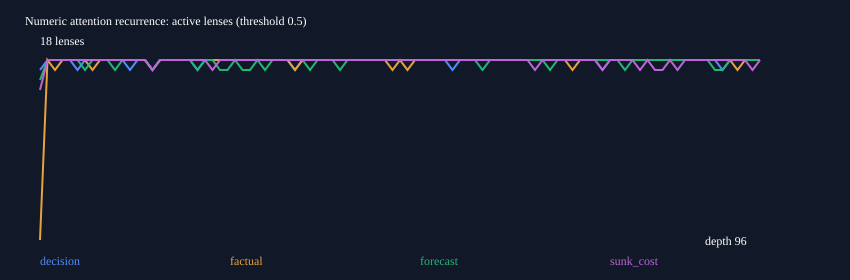

{'jev_calls': 642, 'jev_successes': 642, 'initial_mean_pairwise_L1': 0.3436111111111111, 'final_mean_pairwise_L1': 0.0162037037037037, 'separation_reduction_fraction': 0.9528428994880086, 'chains': {'sunk_cost': {'depth': 96, 'stop': 'depth_cap'}, 'decision': {'depth': 96, 'stop': 'depth_cap'}, 'factual': {'depth': 96, 'stop': 'depth_cap'}, 'forecast': {'depth': 96, 'stop': 'depth_cap'}}, 'tree_nodes': 160, 'tree_depth': 21, 'tree_stop': 'node_cap', 'backward_replays': 18, 'accepted_replays': 7, 'backtrack_restores': 11, 'known_limit_correction': 'Initial tree summary says empty_frontier, but durable results show the first-pass reservation limit stopped it after five nodes. Treat as budget-truncated. Swarm bounded_frontier_drained includes host call-cap exhaustion; not natural collapse.'}


In [4]:
from IPython.display import SVG, display
display(SVG((ROOT / 'assets/recurrence.svg').read_text()))
print(json.loads((ROOT / 'data/recurrence_summary.json').read_text()))

## Candidate inventory
Every downloaded named bias-list entry was catalogued, but verbal proxy tests do not establish human/LLM psychological equivalence. The 750 candidates mostly reuse three tactics, with 30 extra calibration variants. Four cases per strategy cannot establish a reliable efficacy ranking. One source-label extraction was corrected without overwriting the original trial.

In [5]:
candidates = json.loads((ROOT / 'data/debiasing_candidates.json').read_text())
operators = json.loads((ROOT / 'data/reasoning_operators.json').read_text())
print('Candidate strategy pairs:', len(candidates))
print('Named source targets:', len({s['bias_id'] for s in candidates}))
print('Operator vocabulary:', len(operators))
print('First-pass paired effect:', summary['debias_pairs']['intervention'])

Candidate strategy pairs: 750
Named source targets: 240
Operator vocabulary: 800
First-pass paired effect: {'pairs': 3000, 'repairs': 78, 'harms': 79, 'both_correct': 2663, 'both_wrong': 180, 'net_correct_change': -1, 'net_accuracy_change': -0.0003333333333333333}
